In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

df1 = pd.read_csv('One_year_compiled.csv')

# Ejercicio 1

In [2]:
df1.columns

Index(['timestamp', 'pCut::Motor_Torque',
       'pCut::CTRL_Position_controller::Lag_error',
       'pCut::CTRL_Position_controller::Actual_position',
       'pCut::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Actual_position',
       'pSvolFilm::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Lag_error', 'pSpintor::VAX_speed',
       'month', 'day', 'hour', 'sample_Number', 'mode'],
      dtype='object')

In [3]:
df1['mode'].unique()

array(['mode1', 'mode2', 'mode5', 'mode3', 'mode4', 'mode8', 'mode6',
       'mode7'], dtype=object)

In [4]:
df1.head()

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,mode1
1,0.012,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,mode1
2,0.016,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,mode1
3,0.020,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,mode1
4,0.024,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,mode1


In [5]:
df1.describe().round(3)

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number
count,1062912.000,1062912.000,1062912.000,1.062912e+06,1062912.000,1.062912e+06,1062912.000,1062912.000,1062912.000,1062912.000,1062912.000,1062912.000,1062912.000
mean,4.102,-0.121,-0.000,3.371415e+08,1945.795,1.488169e+08,5367.032,0.985,1927.328,5.268,16.536,136187.983,258.874
std,2.365,0.608,0.121,5.466868e+08,4873.922,2.711355e+08,3382.194,0.344,655.905,3.503,8.488,32252.987,149.749
min,0.004,-6.560,-1.888,-2.039056e+09,-9482.574,1.936250e+05,-20.134,-0.914,0.000,1.000,1.000,81158.000,0.000
25%,2.056,-0.370,-0.022,8.626082e+07,-1908.875,2.136702e+07,3032.669,0.838,1500.000,2.000,9.000,111317.000,129.000
50%,4.104,-0.119,0.001,1.919407e+08,2595.520,7.259557e+07,4582.979,0.971,1800.000,4.000,18.000,134818.000,259.000
75%,6.152,0.255,0.024,5.691639e+08,5441.666,1.602507e+08,5823.731,1.106,2280.000,8.000,23.000,161827.000,389.000
max,8.200,3.857,2.022,1.911789e+09,17928.312,1.453671e+09,17972.023,3.568,3600.000,12.000,31.000,223249.000,518.000


In [6]:
# pd.set_option('display.max_rows', None)
df1['hour'].value_counts(ascending=True)

hour
185909.0    1530
183459.0    2049
184835.0    2049
185047.0    2049
185257.0    2049
            ... 
184424.0    2049
115528.0    2049
162156.0    2049
121536.0    4098
113211.0    4098
Name: count, Length: 517, dtype: int64

# Ejercicio 3

In [7]:
df1_copia = df1.copy()
df1_copia

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,mode1
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,mode1
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,mode1
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,mode1
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.179999,-0.277697,-0.023948,194924473,7220.077148,11693928,4610.663086,0.958136,1499.999756,12,28,185909.0,518.0,mode2
1062908,8.183999,-0.285098,-0.022138,194924502,7257.842773,11693946,4618.213379,0.971821,1499.999756,12,28,185909.0,518.0,mode2
1062909,8.187999,-0.155192,-0.034412,194924531,7371.139160,11693964,4582.979004,0.981734,1499.999756,12,28,185909.0,518.0,mode2
1062910,8.191999,-0.371426,0.031594,194924560,7360.839844,11693983,4615.696777,0.987367,1499.999756,12,28,185909.0,518.0,mode2


# Ejercicio 5

In [8]:
df1.drop(columns=["day"])

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,hour,sample_Number,mode
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,184148.0,0.0,mode1
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,184148.0,0.0,mode1
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,184148.0,0.0,mode1
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,184148.0,0.0,mode1
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.179999,-0.277697,-0.023948,194924473,7220.077148,11693928,4610.663086,0.958136,1499.999756,12,185909.0,518.0,mode2
1062908,8.183999,-0.285098,-0.022138,194924502,7257.842773,11693946,4618.213379,0.971821,1499.999756,12,185909.0,518.0,mode2
1062909,8.187999,-0.155192,-0.034412,194924531,7371.139160,11693964,4582.979004,0.981734,1499.999756,12,185909.0,518.0,mode2
1062910,8.191999,-0.371426,0.031594,194924560,7360.839844,11693983,4615.696777,0.987367,1499.999756,12,185909.0,518.0,mode2


# Ejercicio 7

In [9]:
df1_copia.iloc[500:751, 1:5]

,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed
500,-0.131797,0.007229,628395807,2245.330811
501,0.004542,-0.019871,628395816,2293.395996
502,-0.138911,0.018225,628395825,2265.930176
503,-0.136871,0.017830,628395834,2241.897461
504,-0.176290,0.017183,628395843,2200.698730
...,...,...,...,...
746,0.261230,0.081220,628395116,-4892.349121
747,0.365543,0.057757,628395097,-4809.951660
748,0.292283,0.054181,628395077,-4830.550781
749,0.345109,0.017140,628395058,-4789.352051


# Ejercicio 8

In [10]:
consulta = df1_copia["month"] < 6
df1_copia[consulta]

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,mode1
1,0.012,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,mode1
2,0.016,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,mode1
3,0.020,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,mode1
4,0.024,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581911,1.124,-0.124228,0.002363,128813354,1098.632812,271458446,3050.286133,0.790697,1799.999756,5,26,160301.0,283.0,mode2
581912,1.128,-0.087999,-0.008263,128813358,1078.033447,271458458,3004.984619,0.772213,1799.999756,5,26,160301.0,283.0,mode2
581913,1.132,-0.047169,-0.014059,128813363,1019.668579,271458470,3017.568359,0.756565,1799.999756,5,26,160301.0,283.0,mode2
581914,1.136,-0.106502,0.001320,128813367,975.036621,271458482,3042.735840,0.823055,1799.999756,5,26,160301.0,283.0,mode2


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062912 entries, 0 to 1062911
Data columns (total 14 columns):
 #   Column                                                Non-Null Count    Dtype  
---  ------                                                --------------    -----  
 0   timestamp                                             1062912 non-null  float64
 1   pCut::Motor_Torque                                    1062912 non-null  float64
 2   pCut::CTRL_Position_controller::Lag_error             1062912 non-null  float64
 3   pCut::CTRL_Position_controller::Actual_position       1062912 non-null  int64  
 4   pCut::CTRL_Position_controller::Actual_speed          1062912 non-null  float64
 5   pSvolFilm::CTRL_Position_controller::Actual_position  1062912 non-null  int64  
 6   pSvolFilm::CTRL_Position_controller::Actual_speed     1062912 non-null  float64
 7   pSvolFilm::CTRL_Position_controller::Lag_error        1062912 non-null  float64
 8   pSpintor::VAX_speed             

# Graficos

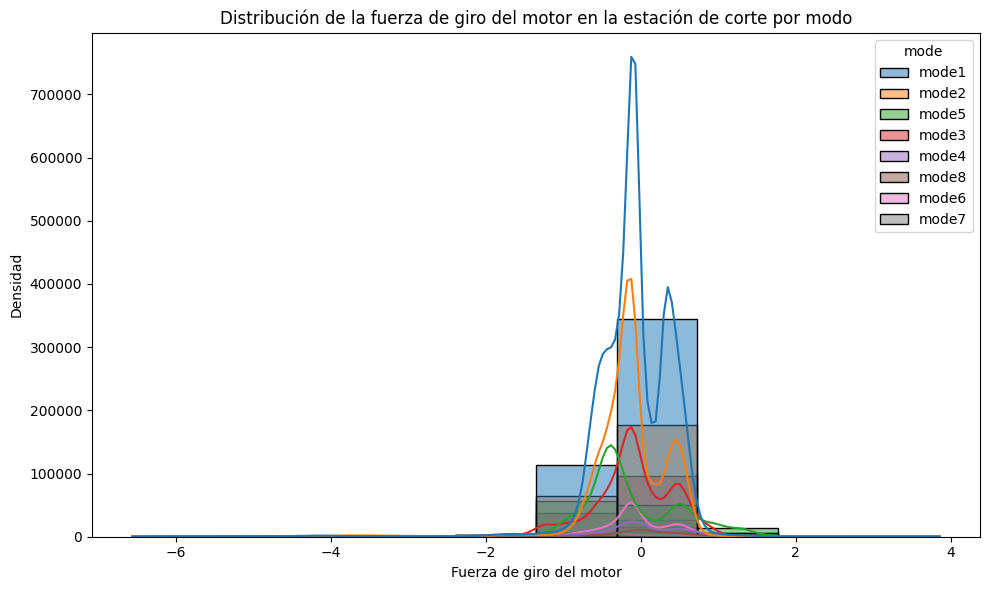

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data = df1_copia,
    x = 'pCut::Motor_Torque',
    hue = 'mode',
    kde = True,
    alpha = 0.5,
    ax = ax,
    bins = 10
)

ax.set_title('Distribución de la fuerza de giro del motor en la estación de corte por modo')
ax.set_xlabel('Fuerza de giro del motor')
ax.set_ylabel('Densidad')
plt.tight_layout()
plt.show()

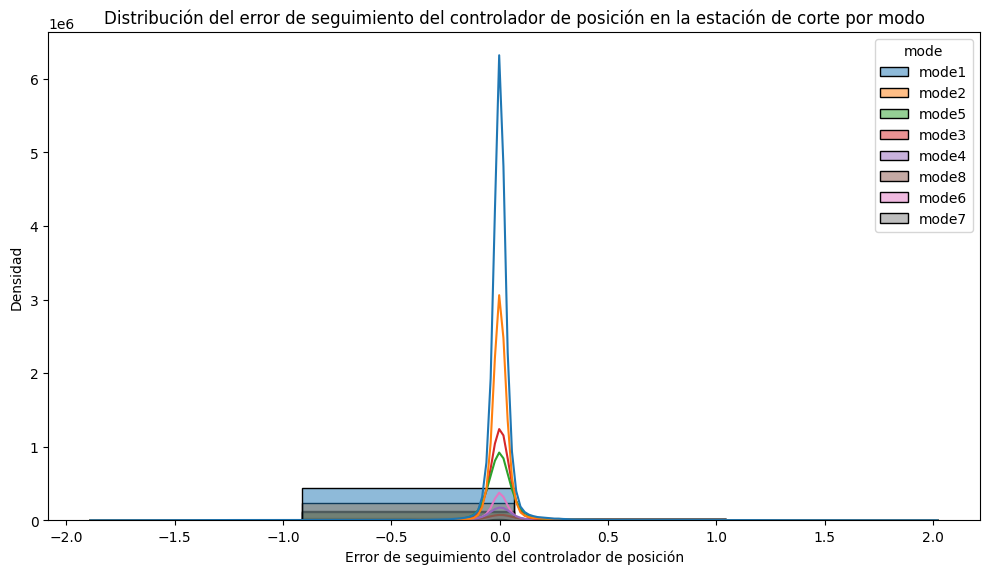

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data = df1_copia,
    x = 'pCut::CTRL_Position_controller::Lag_error',
    hue = 'mode',
    kde = True,
    alpha = 0.5,
    ax = ax,
    bins = 4
)

ax.set_title('Distribución del error de seguimiento del controlador de posición en la estación de corte por modo')
ax.set_xlabel('Error de seguimiento del controlador de posición')
ax.set_ylabel('Densidad')
plt.tight_layout()
plt.show()

<Axes: xlabel='pCut::CTRL_Position_controller::Actual_speed', ylabel='Count'>

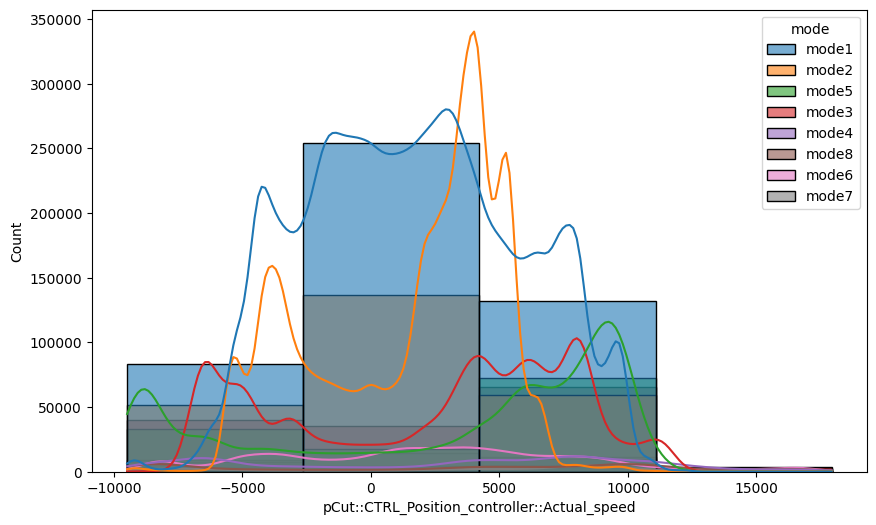

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df1,
    x='pCut::CTRL_Position_controller::Actual_speed',
    bins=4,
    hue='mode',
    kde=True,
    alpha=0.6,
    ax=ax
)

<Axes: xlabel='pSvolFilm::CTRL_Position_controller::Actual_position', ylabel='Count'>

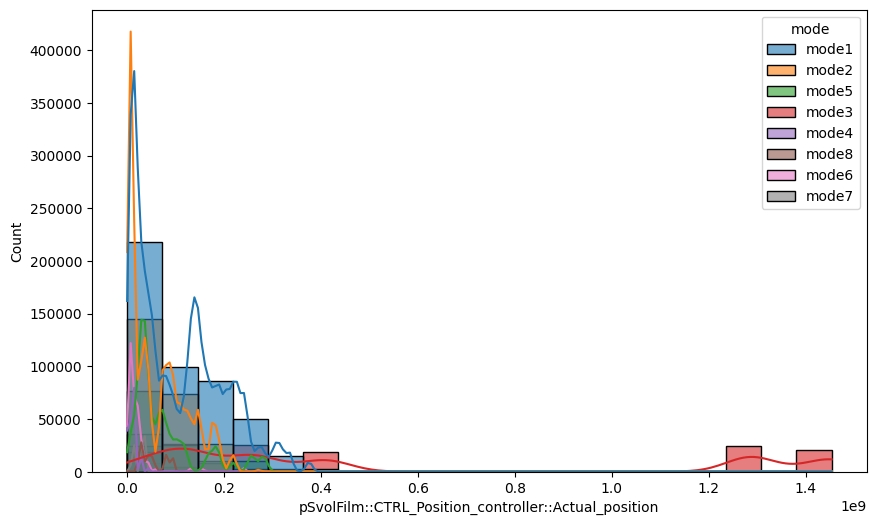

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df1,
    x='pSvolFilm::CTRL_Position_controller::Actual_position',
    bins=20,
    hue='mode',
    kde=True,
    alpha=0.6,
    ax=ax
)

<Axes: xlabel='pSvolFilm::CTRL_Position_controller::Actual_speed', ylabel='Count'>

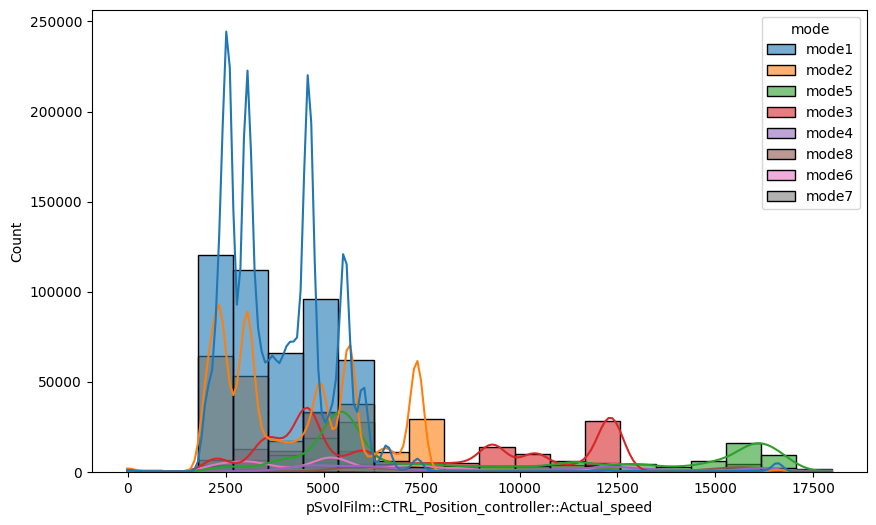

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df1,
    x='pSvolFilm::CTRL_Position_controller::Actual_speed',
    bins=20,
    hue='mode',
    kde=True,
    alpha=0.6,
    ax=ax
)

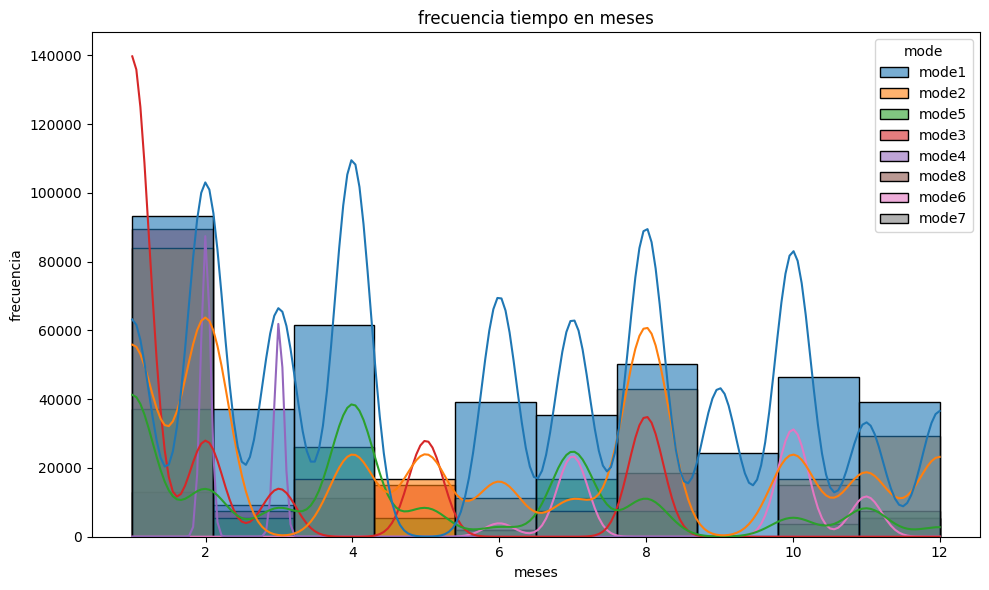

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    bins=10,
    data=df1_copia,
    x='month',
    hue='mode',
    kde=True,
    stat='frequency',
    common_norm=False,
    alpha=0.6,
    ax=ax
)
ax.set_title('frecuencia tiempo en meses')
ax.set_xlabel('meses')
ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

In [18]:
df1_copia1 = df1.copy()
df1_copia1 = np.round(df1_copia, 1)
df1_copia1

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.0,0.2,0.0,628392628,-920.1,5298555,2441.2,0.9,1380.0,1,4,184148.0,0.0,mode1
1,0.0,0.3,0.0,628392625,-937.3,5298565,2453.8,0.9,1380.0,1,4,184148.0,0.0,mode1
2,0.0,0.3,-0.0,628392621,-951.0,5298575,2476.5,0.9,1380.0,1,4,184148.0,0.0,mode1
3,0.0,0.4,-0.1,628392617,-1019.7,5298585,2501.6,0.8,1380.0,1,4,184148.0,0.0,mode1
4,0.0,0.5,-0.0,628392613,-1023.1,5298595,2519.3,0.9,1380.0,1,4,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.2,-0.3,-0.0,194924473,7220.1,11693928,4610.7,1.0,1500.0,12,28,185909.0,518.0,mode2
1062908,8.2,-0.3,-0.0,194924502,7257.8,11693946,4618.2,1.0,1500.0,12,28,185909.0,518.0,mode2
1062909,8.2,-0.2,-0.0,194924531,7371.1,11693964,4583.0,1.0,1500.0,12,28,185909.0,518.0,mode2
1062910,8.2,-0.4,0.0,194924560,7360.8,11693983,4615.7,1.0,1500.0,12,28,185909.0,518.0,mode2


<Axes: ylabel='timestamp'>

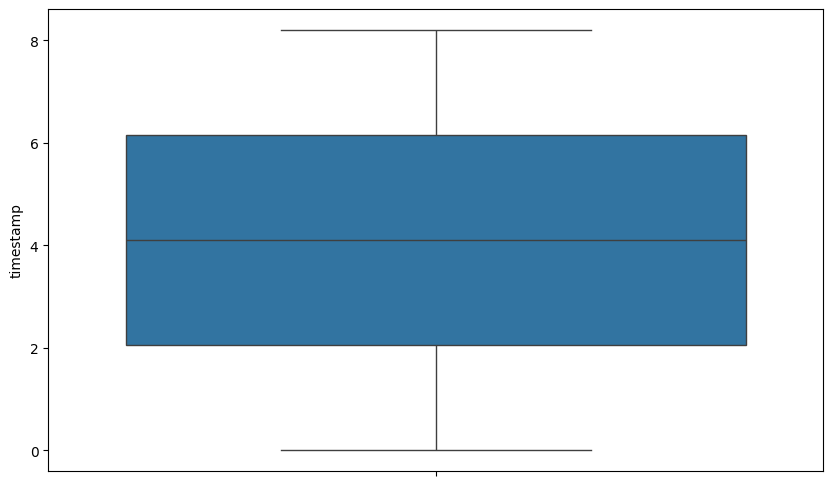

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='timestamp',
    ax=ax
)

<Axes: ylabel='pCut::Motor_Torque'>

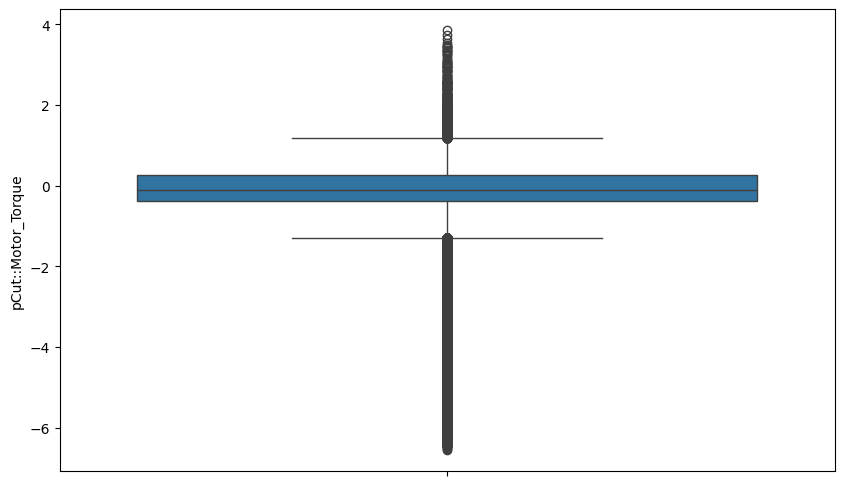

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::Motor_Torque',
    ax=ax
)

<Axes: ylabel='pCut::CTRL_Position_controller::Lag_error'>

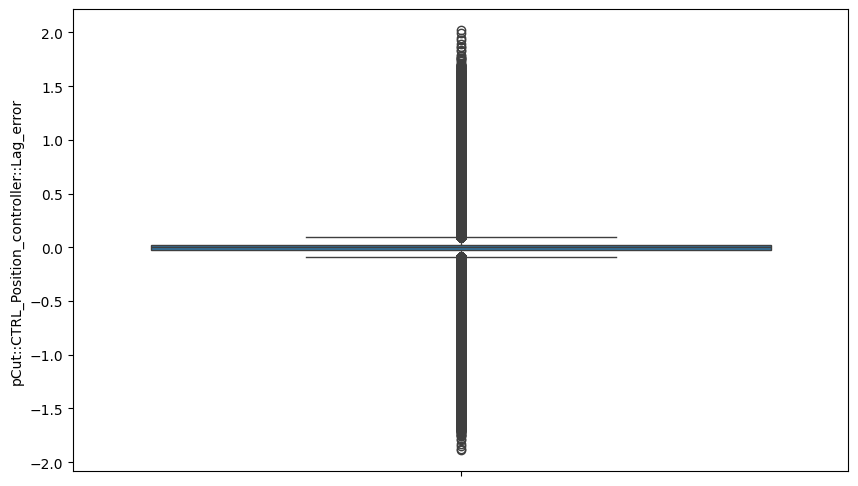

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::CTRL_Position_controller::Lag_error',
    ax=ax
)

<Axes: ylabel='pCut::CTRL_Position_controller::Actual_position'>

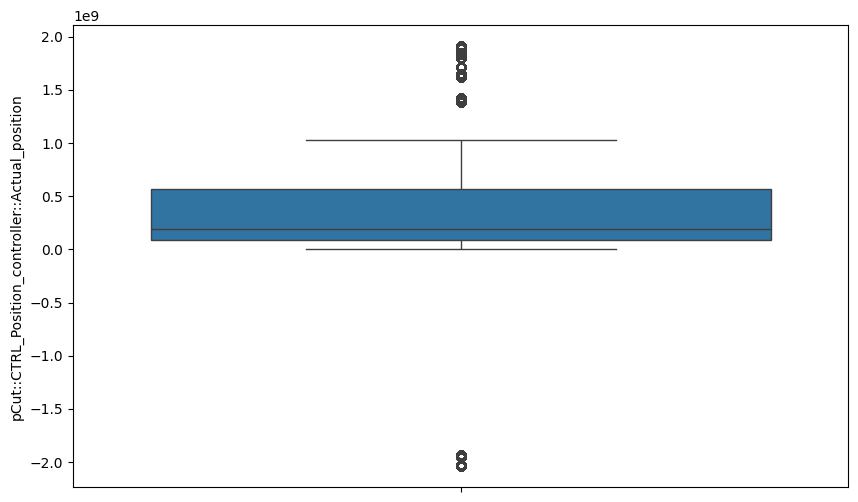

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::CTRL_Position_controller::Actual_position',
    ax=ax
)

<Axes: ylabel='pCut::CTRL_Position_controller::Actual_speed'>

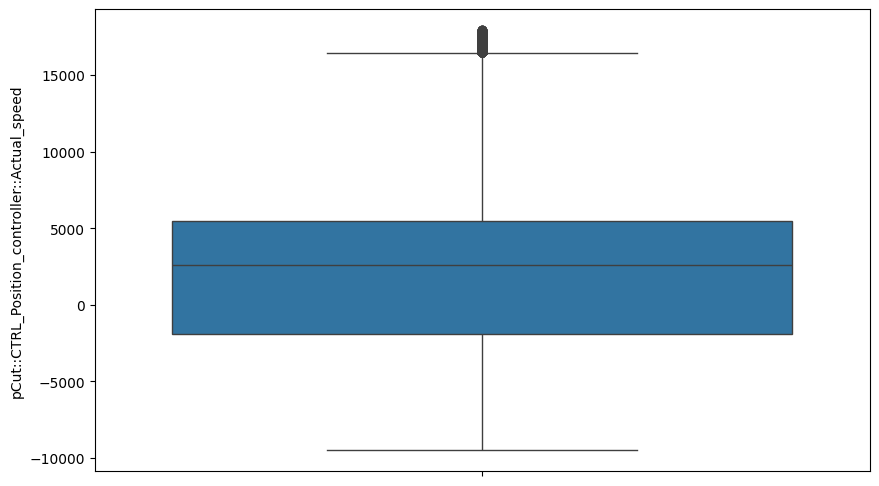

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::CTRL_Position_controller::Actual_speed',
    ax=ax
)

<Axes: ylabel='pSvolFilm::CTRL_Position_controller::Actual_position'>

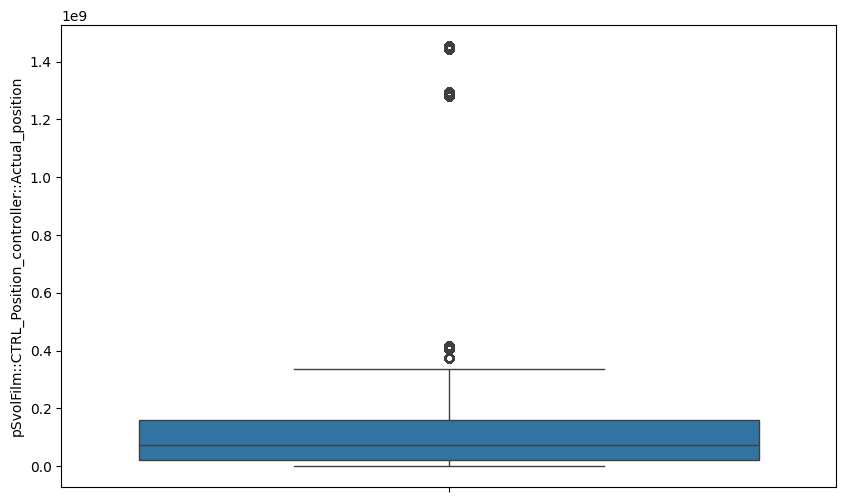

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSvolFilm::CTRL_Position_controller::Actual_position',
    ax=ax
)

<Axes: ylabel='pSvolFilm::CTRL_Position_controller::Actual_speed'>

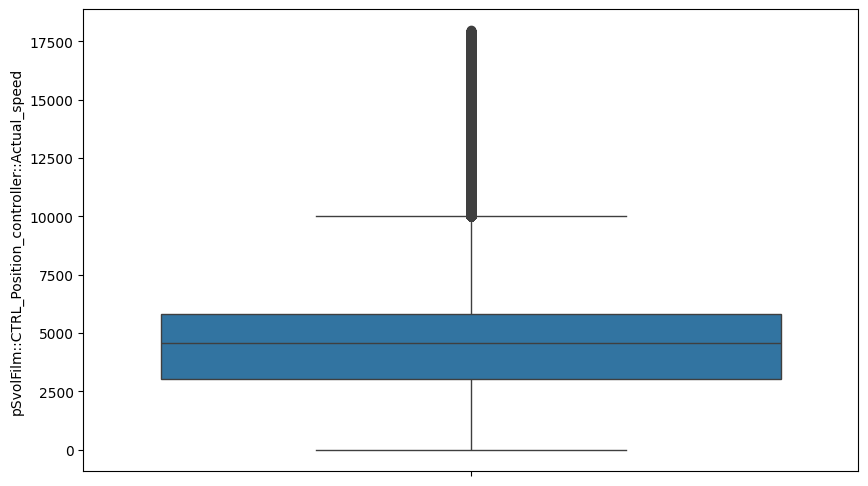

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSvolFilm::CTRL_Position_controller::Actual_speed',
    ax=ax
)

<Axes: ylabel='pSvolFilm::CTRL_Position_controller::Lag_error'>

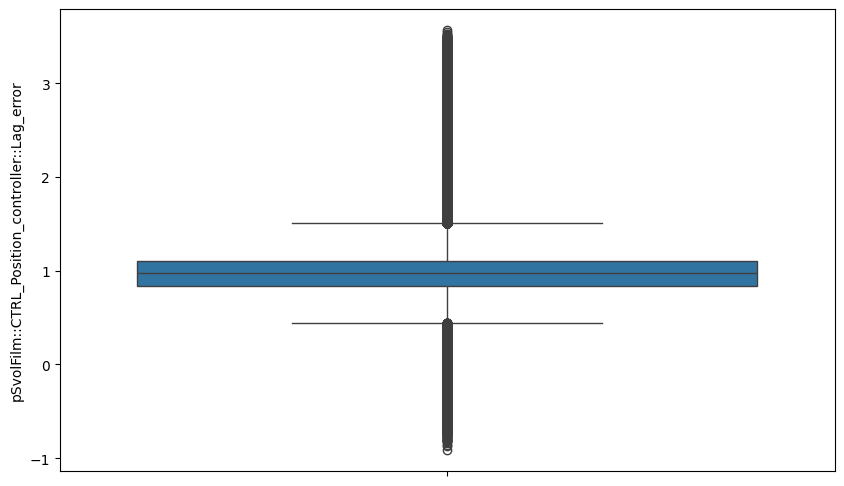

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSvolFilm::CTRL_Position_controller::Lag_error',
    ax=ax
)

<Axes: ylabel='pSpintor::VAX_speed'>

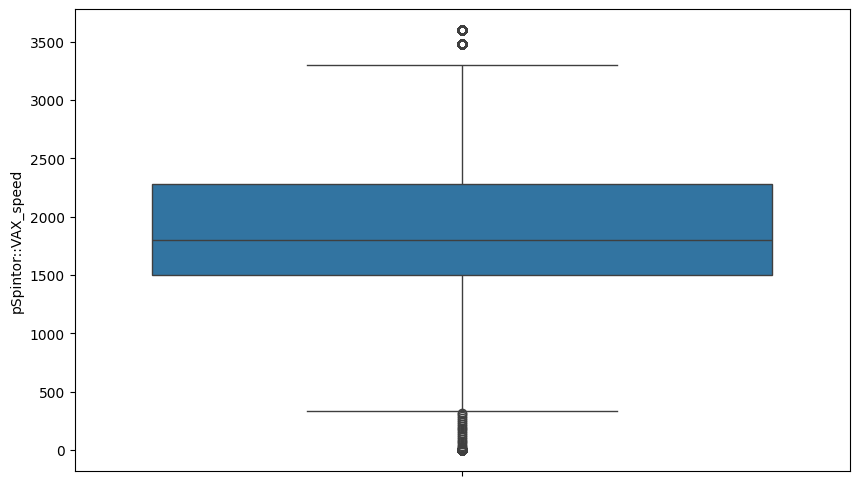

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSpintor::VAX_speed',
    ax=ax
)

<Axes: ylabel='month'>

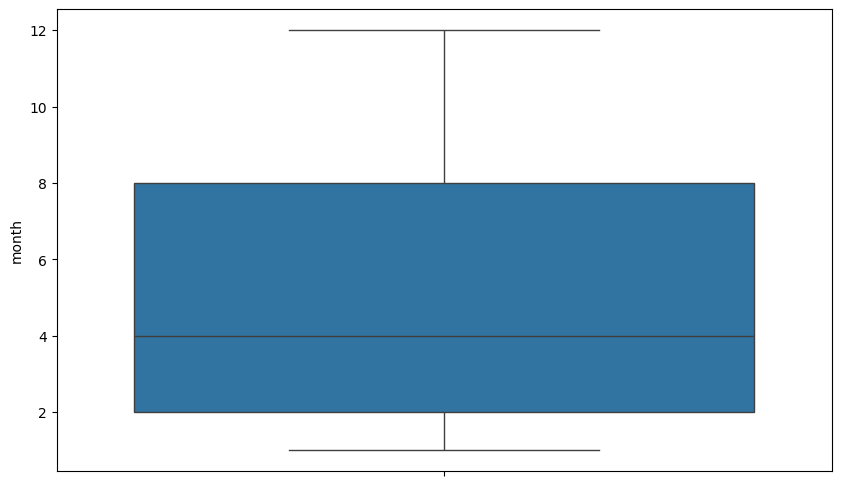

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='month',
    ax=ax
)

<Axes: ylabel='day'>

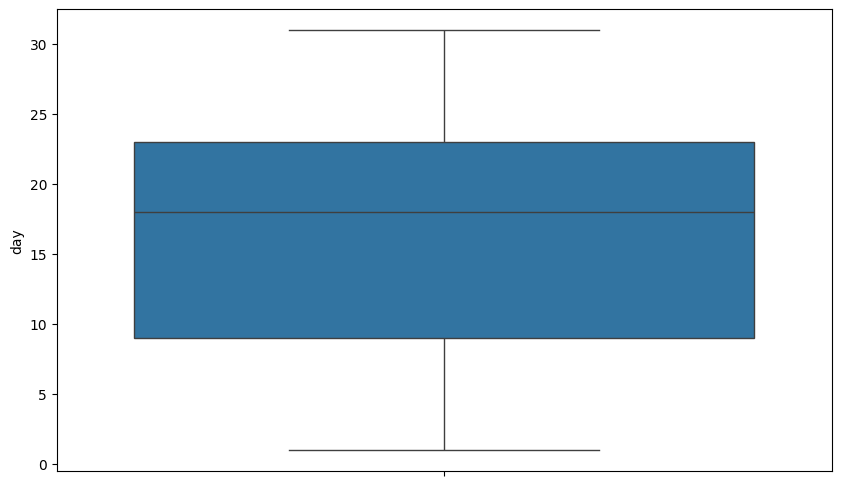

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='day',
    ax=ax
)

<Axes: ylabel='hour'>

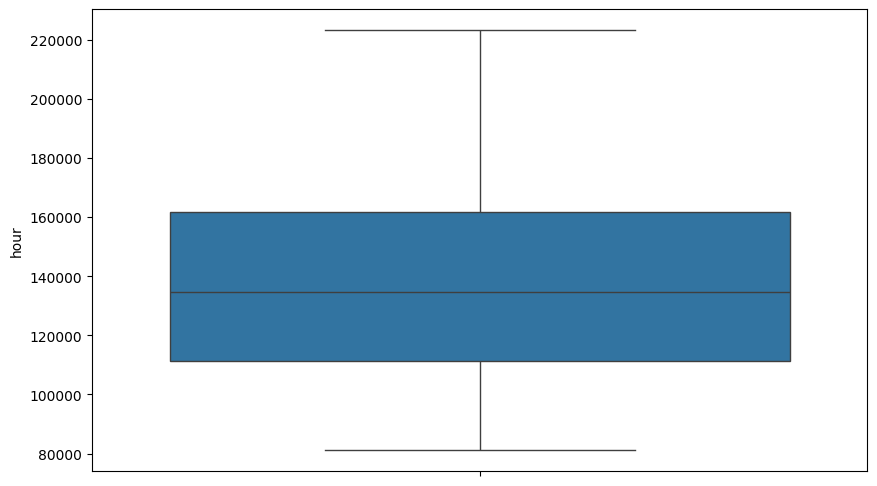

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='hour',
    ax=ax
)

<Axes: ylabel='sample_Number'>

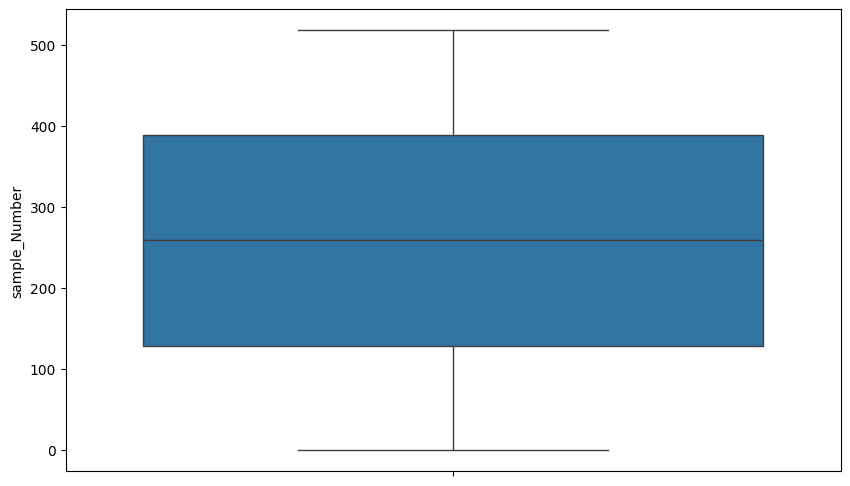

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='sample_Number',
    ax=ax
)

# Columnas Nuevas

In [ ]:
# Creación de columna nueva de avería general
s1 = 1.7
s2 = 3

df1_copia["averia"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > s1) |
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > s2)
).astype(int)

df1_copia["averia"].value_counts()

averia
0    536604
1    526308
Name: count, dtype: int64

In [ ]:
# Creación de columna nueva de avería sensor 1
df1_copia["s1"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > s1)
).astype(int)

df1_copia["s1"].value_counts()

s1
0    540317
1    522595
Name: count, dtype: int64

In [ ]:
# Creación de columna nueva de avería sensor 2
df1_copia["s2"] = (
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > s2)
).astype(int)

df1_copia["s2"].value_counts()

s2
0    1050585
1      12327
Name: count, dtype: int64

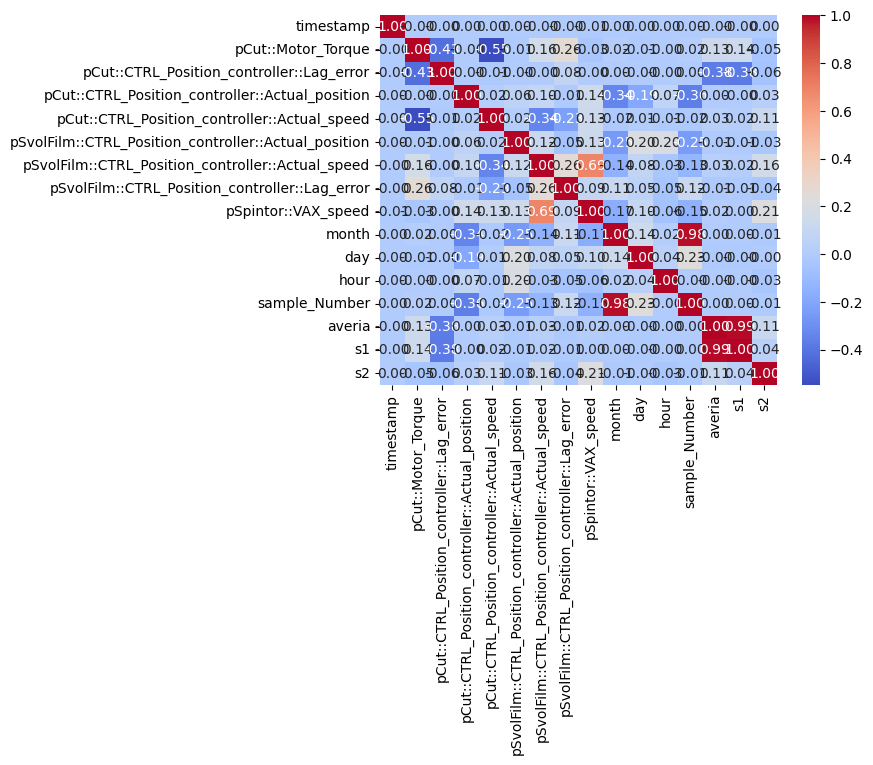

In [35]:
df1_copia1 = df1_copia.drop("mode", axis=1).copy()
matriz_corr = df1_copia1.corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

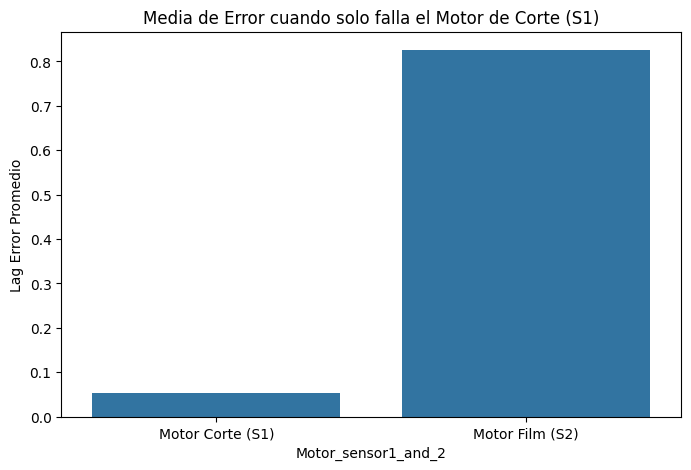

In [36]:
filtro= df1_copia[(df1_copia["s1"] == 0) & (df1_copia["s2"] == 1)]

df1_copia1 = filtro[['pCut::CTRL_Position_controller::Lag_error', 
                    'pSvolFilm::CTRL_Position_controller::Lag_error']].mean().reset_index()
df1_copia1.columns = ['Motor_sensor1_and_2', 'Error_Medio']

plt.figure(figsize=(8, 5))
sns.barplot(data=df1_copia1, x='Motor_sensor1_and_2', y='Error_Medio')

plt.title('Media de Error cuando solo falla el Motor de Corte (S1)')
plt.ylabel('Lag Error Promedio')
plt.xticks([0, 1], ['Motor Corte (S1)', 'Motor Film (S2)'])
plt.show()

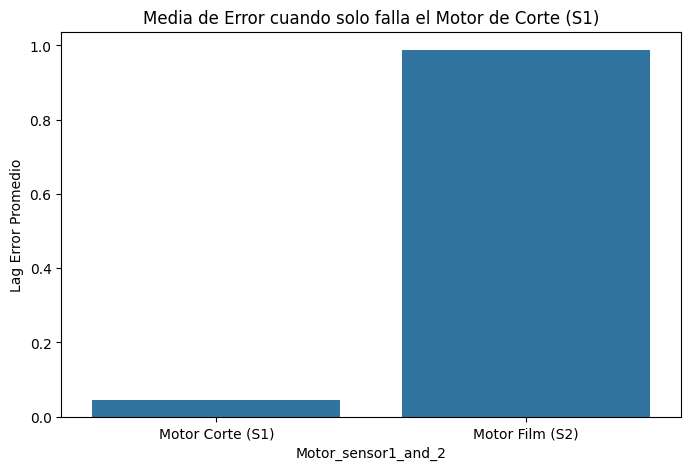

In [37]:
averia_filtrada = df1_copia[df1_copia["averia"]==0].copy()
df1_copia1 = averia_filtrada[['pCut::CTRL_Position_controller::Lag_error', 
                    'pSvolFilm::CTRL_Position_controller::Lag_error']].mean().reset_index()
df1_copia1.columns = ['Motor_sensor1_and_2', 'Error_Medio']

plt.figure(figsize=(8, 5))
sns.barplot(data=df1_copia1, x='Motor_sensor1_and_2', y='Error_Medio')

plt.title('Media de Error cuando solo falla el Motor de Corte (S1)')
plt.ylabel('Lag Error Promedio')
plt.xticks([0, 1], ['Motor Corte (S1)', 'Motor Film (S2)'])
plt.show()

C:\Users\Angel\AppData\Local\Temp\ipykernel_12852\338157085.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_plot, x='Motor_sensor1_and_2', y='Error_Medio', palette='viridis')


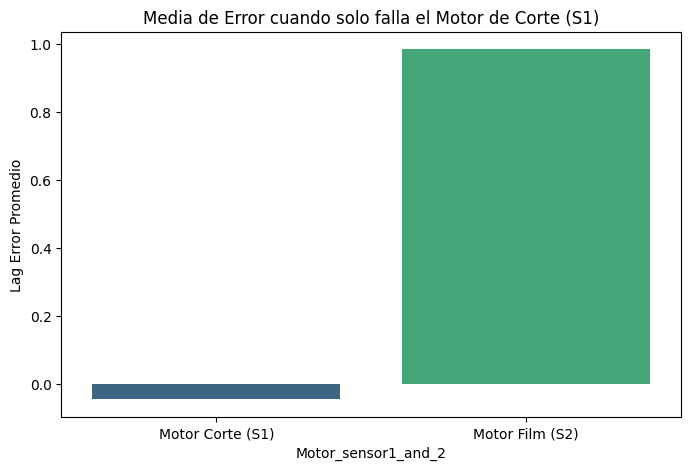

In [38]:
df_caso3 = df1_copia[(df1_copia['s1'] == 1) & (df1_copia['s2'] == 0)]
data_plot = df_caso3[['pCut::CTRL_Position_controller::Lag_error', 
                    'pSvolFilm::CTRL_Position_controller::Lag_error']].mean().reset_index()
data_plot.columns = ['Motor_sensor1_and_2', 'Error_Medio']

# 3. Dibujamos siguiendo un barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=data_plot, x='Motor_sensor1_and_2', y='Error_Medio', palette='viridis')

plt.title('Media de Error cuando solo falla el Motor de Corte (S1)')
plt.ylabel('Lag Error Promedio')
plt.xticks([0, 1], ['Motor Corte (S1)', 'Motor Film (S2)'])
plt.show()

# Preprocesamiento Para Random Forest Para Averia

In [39]:
df1_copia1 = df1_copia.drop("mode", axis=1)
X = df1_copia1.drop("averia", axis=1)
X = X.drop("s1", axis=1)
X = X.drop("s2", axis=1)

X1 = np.array(df1_copia[['mode']])

y = df1_copia["averia"]

encoder = OrdinalEncoder(
    categories=[['mode0', 'mode1', 'mode2', 'mode3', 'mode4', 'mode5', 'mode6', 'mode7', 'mode8']]
)
X['mode'] = encoder.fit_transform(X1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = df1_copia["averia"]

# PCA Para Random Forest Para Averia

In [40]:
pca = PCA(n_components=9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Forma original: {X.shape}")
print(f"Forma reducida: {X_pca.shape}")
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Varianza acumulada total: {pca.explained_variance_ratio_.sum():.3f}")

Forma original: (1062912, 14)
Forma reducida: (1062912, 9)
Varianza explicada por componente: [0.192 0.154 0.128 0.094 0.083 0.071 0.07  0.056 0.049]
Varianza acumulada total: 0.897


# Regresion Logistica Para Averia

In [41]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --------------------
# MÉTODOS DE BALANCEO DE CLASES
# --------------------
# 1. Sobremuestreo aleatorio
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# 2. SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. Submuestreo aleatorio
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# 4. NearMiss (submuestreo basado en distancia)
nearmiss = NearMiss()
X_train_nm, y_train_nm = nearmiss.fit_resample(X_train, y_train)

In [42]:
# --------------------
# EVALUACIÓN DE MÉTODOS DE BALANCEO
# --------------------
resultados_balanceo = {}

def evaluar_balanceo(X_train_resampled, y_train_resampled, metodo):
    model = LogisticRegression(C=0.1, solver='liblinear', max_iter=500)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred) * 100
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1]) * 100
    resultados_balanceo[metodo] = (f1, auc)
    print(f"\nResultados con {metodo}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_pred) * 100:.2f}%")
    print(f"Recall: {recall_score(y_test, y_pred) * 100:.2f}%")
    print(f"F1-Score: {f1:.2f}%")
    print(f"AUC-ROC: {auc:.2f}%")

evaluar_balanceo(X_train_ros, y_train_ros, "Sobremuestreo Aleatorio")
evaluar_balanceo(X_train_smote, y_train_smote, "SMOTE")
evaluar_balanceo(X_train_rus, y_train_rus, "Submuestreo Aleatorio")
evaluar_balanceo(X_train_nm, y_train_nm, "NearMiss")

# Seleccionar el mejor método de balanceo
mejor_metodo = max(resultados_balanceo, key=lambda k: resultados_balanceo[k])
print(f"\nEl mejor método de balanceo es: {mejor_metodo} con F1-Score: {resultados_balanceo[mejor_metodo][0]:.2f}% y AUC-ROC: {resultados_balanceo[mejor_metodo][1]:.2f}%")

# Obtener los datos balanceados del mejor método encontrado
if mejor_metodo == "Sobremuestreo Aleatorio":
    X_train_resampled, y_train_resampled = X_train_ros, y_train_ros
elif mejor_metodo == "SMOTE":
    X_train_resampled, y_train_resampled = X_train_smote, y_train_smote
elif mejor_metodo == "Submuestreo Aleatorio":
    X_train_resampled, y_train_resampled = X_train_rus, y_train_rus
elif mejor_metodo == "NearMiss":
    X_train_resampled, y_train_resampled = X_train_nm, y_train_nm


Resultados con Sobremuestreo Aleatorio:
Accuracy: 98.67%
Precision: 98.64%
Recall: 98.67%
F1-Score: 98.65%
AUC-ROC: 99.55%

Resultados con SMOTE:
Accuracy: 98.67%
Precision: 98.65%
Recall: 98.66%
F1-Score: 98.66%
AUC-ROC: 99.55%

Resultados con Submuestreo Aleatorio:
Accuracy: 98.67%
Precision: 98.64%
Recall: 98.67%
F1-Score: 98.66%
AUC-ROC: 99.55%

Resultados con NearMiss:
Accuracy: 98.68%
Precision: 98.70%
Recall: 98.62%
F1-Score: 98.66%
AUC-ROC: 99.55%

El mejor método de balanceo es: NearMiss con F1-Score: 98.66% y AUC-ROC: 99.55%


In [43]:
# --------------------
# MÉTODO 1: Ajuste manual de hiperparámetros
# --------------------
manual_model = LogisticRegression(C=0.1, solver='liblinear', max_iter=500)  # Ejemplo de hiperparámetros ajustados manualmente
manual_model.fit(X_train_resampled, y_train_resampled)  # Entrenar modelo

# Predicciones
y_pred_manual = manual_model.predict(X_test)

# Evaluación del modelo ajustado manualmente
print("\nResultados con ajuste manual de hiperparámetros:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_manual) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_manual) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_manual) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_manual) * 100:.2f}%")
print(f"AUC-ROC: {roc_auc_score(y_test, manual_model.predict_proba(X_test)[:,1]) * 100:.2f}%")


Resultados con ajuste manual de hiperparámetros:
Accuracy: 98.68%
Precision: 98.70%
Recall: 98.62%
F1-Score: 98.66%
AUC-ROC: 99.55%


In [44]:
# --------------------
# MÉTODO 2: Ajuste automático con GridSearchCV
# --------------------
parametros = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],  # Diferentes valores de regularización
    "solver": ["liblinear", "lbfgs"]  # Diferentes algoritmos de optimización
}

# Configurar GridSearchCV
grid_search = GridSearchCV(LogisticRegression(max_iter=500), parametros, cv=5, scoring="accuracy", n_jobs=-1)

grid_search.fit(X_train_resampled, y_train_resampled)  # Entrenar búsqueda de hiperparámetros

# Mejor modelo encontrado
best_model = grid_search.best_estimator_

# Predicciones del mejor modelo
y_pred_best = best_model.predict(X_test)

# Evaluación del mejor modelo
print("\nResultados con ajuste automático de hiperparámetros:")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en validación cruzada: {grid_search.best_score_ * 100:.2f}%")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_best) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_best) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_best) * 100:.2f}%")
print(f"AUC-ROC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]) * 100:.2f}%")


Resultados con ajuste automático de hiperparámetros:
Mejores parámetros: {'C': 100, 'solver': 'lbfgs'}
Mejor Accuracy en validación cruzada: 96.48%
Accuracy: 98.70%
Precision: 98.72%
Recall: 98.64%
F1-Score: 98.68%
AUC-ROC: 99.55%


In [45]:
# --------------------
# ENTRENAMIENTO FINAL Y EVALUACIÓN
# --------------------

# Entrenar el mejor modelo con los datos balanceados
best_model.fit(X_train_resampled, y_train_resampled)

# Realizar predicciones finales con el mejor modelo y el mejor balanceo
y_pred_final = best_model.predict(X_test)

# Crear DataFrame de resultados
resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred_final
})

# Mapear valores 0 y 1 a etiquetas comprensibles
resultados["Real"] = resultados["Real"].map({0: "No clase y", 1: "clase y"})
resultados["Predicción"] = resultados["Predicción"].map({0: "No clase y", 1: "clase y"})

# Mostrar las primeras filas de la tabla
print(resultados.head(10))

         Real  Predicción
0  No clase y  No clase y
1  No clase y  No clase y
2  No clase y  No clase y
3  No clase y  No clase y
4  No clase y  No clase y
5     clase y     clase y
6     clase y     clase y
7     clase y     clase y
8     clase y     clase y
9     clase y     clase y


# Random Forest Para Averia

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [47]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [48]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
y_pred = model.predict(X_test)

In [ ]:
# Análisis de precisión del algoritmo con columna avería
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del Random Forest: {accuracy * 100:.2f}%')

Precisión del Random Forest: 100.00%


# Nuevas Predicciones Random Forest Para Averia

In [51]:
df_manual = pd.read_csv("One_year_compiled_manual.csv")

In [52]:
X = df_manual.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.34164079,  0.97935848,  0.67154367,  0.8587478 , -1.57727653,
        -0.33030254, -1.72933826, -0.82451828, -0.89496547, -1.23717915,
         1.1717002 ,  1.18073444, -1.34164079, -0.96225045],
       [-0.4472136 , -1.00200887, -1.72072385, -0.23865865,  0.92096873,
        -0.31566451,  0.66546516,  1.61945274,  0.17432198,  1.40213637,
        -0.39056673, -0.51467912, -0.4472136 ,  0.57735027],
       [ 0.4472136 , -0.99777804,  0.6619746 , -1.53750923,  0.80178106,
        -1.01541467,  0.5497176 , -0.83426353, -0.84570171, -0.57735027,
         0.65094455, -1.36238589,  0.4472136 ,  1.34715063],
       [ 1.34164079,  1.02042843,  0.38720559,  0.91742008, -0.14547326,
         1.66138172,  0.5141555 ,  0.03932907,  1.5663452 ,  0.41239305,
        -1.43207802,  0.69633057,  1.34164079, -0.96225045]])

In [53]:
prediccion = model.predict(X_scaled)[0]

probabilidad = model.predict_proba(X_scaled)[0][prediccion]*100

In [54]:
resultado = "Avería" if prediccion == 1 else "Me niego a averiarme"

print(f"\nPredicción: {resultado} ({probabilidad:.2f}% de confianza)")


Predicción: Me niego a averiarme (99.00% de confianza)


# PCA Y Preprocesamiento Para Random Forest para s1 y s2

In [55]:
# Definimos el orden de los modos para que sean números
orden_modos = ['mode0', 'mode1', 'mode2', 'mode3', 'mode4', 'mode5', 'mode6', 'mode7', 'mode8']
df1_copia['mode'] = df1_copia['mode'].map({modo: i for i, modo in enumerate(orden_modos)})

# Creamos la X definitiva quitando lo que NO son sensores
# Usamos errors='ignore' por si ya habías borrado alguna antes
columnas_sobran = ['averia', 's1', 's2', 'timestamp', 'sample_Number']
X = df1_copia.drop(columns=columnas_sobran, errors='ignore')

# Limpiamos cualquier valor nulo que haya quedado para evitar errores en el PCA
X = X.dropna()
y_s1 = df1_copia.loc[X.index, 's1'] # Aseguramos que 'y' tenga las mismas filas que 'X'

In [56]:
# Aquí está todo lo que necesitas en una sola pieza
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),       # Paso 1: Escalado automático
    ('pca', PCA(n_components=0.90)),    # Paso 2: PCA al 90% automático
    ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)) # Paso 3: Clasificador
])

# 3. Entrenamiento y Evaluación para S1
X_train, X_test, y_train, y_test = train_test_split(X, y_s1, test_size=0.2, random_state=42)

print("Entrenamiento modelo para motor torque S1.")
pipeline_final.fit(X_train, y_train)

# Resultado final
y_pred = pipeline_final.predict(X_test)
print("\n" + "="*60)
print("--- RESULTADOS FINALES PARA S1 --- ")
print("="*60)

print(classification_report(y_test, y_pred))

Entrenamiento modelo para motor torque S1.

--- RESULTADOS FINALES PARA S1 --- 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95    108414
           1       0.94      0.95      0.94    104169

    accuracy                           0.95    212583
   macro avg       0.95      0.95      0.95    212583
weighted avg       0.95      0.95      0.95    212583



In [57]:
# 1. Definimos el nuevo objetivo (y) para s2
# Usamos el mismo índice de X por si hubo limpieza de nulos
y_s2 = df1_copia.loc[X.index, 's2']

# 2. Dividimos los datos (importante hacer un nuevo split para s2)
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X, y_s2, test_size=0.2, random_state=42
)

# 3. Entrenamos el MISMO pipeline pero con los datos de s2
# El pipeline se reinicia internamente al llamar a .fit()
print("Iniciando entrenamiento para el Motor Film (S2)...")
pipeline_final.fit(X_train_s2, y_train_s2)

# 4. Resultados para s2
y_pred_s2 = pipeline_final.predict(X_test_s2)

print("\n" + "="*60)
print(" --- RESULTADOS FINALES PARA S2 --- ")
print("="*60)
print(classification_report(y_test_s2, y_pred_s2))

Iniciando entrenamiento para el Motor Film (S2)...

 --- RESULTADOS FINALES PARA S2 --- 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    210136
           1       0.97      0.94      0.95      2447

    accuracy                           1.00    212583
   macro avg       0.98      0.97      0.98    212583
weighted avg       1.00      1.00      1.00    212583

